## Brief W2V pooling cluster analysis

In [1]:
from utils.ml import data_dir, tokenize, vectorize, load_data, prepare_data_pipeline
from pyspark.sql import functions as F
from pyspark.ml.clustering import KMeans
from pyspark.ml.stat import Summarizer
from pyspark.ml.feature import Normalizer
import matplotlib.pyplot as plt
import seaborn as sns

session_data = load_data(data_dir)
df = prepare_data_pipeline(session_data, create_features_only=True)
sequences, tokens = tokenize(session_data)
melted_sequences, vectors = vectorize(sequences, return_vocabulary=True)
pooled = melted_sequences.groupBy("Session ID").agg(Summarizer.mean(F.col("vector")).alias("context"))
normalized = Normalizer(inputCol="context", outputCol="context_norm").transform(pooled)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/23 11:49:52 WARN Utils: Your hostname, DESKTOP-UQF5BSK, resolves to a loopback address: 127.0.1.1; using 172.24.225.163 instead (on interface eth0)
26/04/23 11:49:52 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/23 11:49:54 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


TOKENIZED DF:


+----+-----+---+-----+-------+----------+--------------------+
|year|month|day|order|country|session ID|            sequence|
+----+-----+---+-----+-------+----------+--------------------+
|2008|    4|  1|    9|     29|         1|[197, 149, 51, 91...|
|2008|    4|  1|   10|     29|         2|[87, 12, 215, 9, ...|
+----+-----+---+-----+-------+----------+--------------------+
only showing top 2 rows
TOKEN INFO: 


+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+---+
|page 1 (main category)|page 2 (clothing model)|colour|location|model photography|price|price 2|page| id|
+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+---+
|                     4|                    P51|     9|       5|                1|   28|      2|   3|  0|
|                     4|                    P57|     4|       1|                1|   43|      1|   4|  1|
+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+---+
only showing top 2 rows


+---+----+-----+---+-------+----------+--------------------+
| id|year|month|day|country|session ID|              vector|
+---+----+-----+---+-------+----------+--------------------+
|197|2008|    4|  1|     29|         1|[0.28318807482719...|
|149|2008|    4|  1|     29|         1|[0.28619453310966...|
| 51|2008|    4|  1|     29|         1|[-0.0887719988822...|
| 91|2008|    4|  1|     29|         1|[-0.1072944700717...|
|111|2008|    4|  1|     29|         1|[0.03454396501183...|
+---+----+-----+---+-------+----------+--------------------+
only showing top 5 rows


### Fitting on the best observed setup

In [2]:
model = KMeans(featuresCol="context_norm", predictionCol="pred", seed=52, maxIter=50, k = 6).fit(normalized)
model.write().overwrite().save("kmeans_w2v")

### Clustering

In [3]:
#transformed df will have a lot of garbage associeted with pipeline transformations so easier to select and join
model_output = model.transform(normalized)
clusters = model_output.select("session ID", "pred")
df = df.join(clusters, on = "session ID", how = "left")
df.show(5)

+----------+----+-----+---+-----+-------+-------------+------+--------+-----------------+-----+-------+----+-----+------------+------------+----+
|session ID|year|month|day|order|country|main_category|colour|location|model photography|price|price 2|page|index|model_letter|model_number|pred|
+----------+----+-----+---+-----+-------+-------------+------+--------+-----------------+-----+-------+----+-----+------------+------------+----+
|         1|2008|    4|  1|    1|      0|            1|     1|       5|                1|   28|      2|   1|    0|           A|          13|   5|
|         1|2008|    4|  1|    2|      0|            1|     1|       6|                1|   33|      2|   1|    1|           A|          16|   5|
|         1|2008|    4|  1|    3|      0|            2|    10|       2|                1|   52|      1|   1|    2|           B|           4|   5|
|         1|2008|    4|  1|    4|      0|            2|     6|       6|                2|   38|      2|   1|    3|          

## Analysis

Some 3D space visualizations

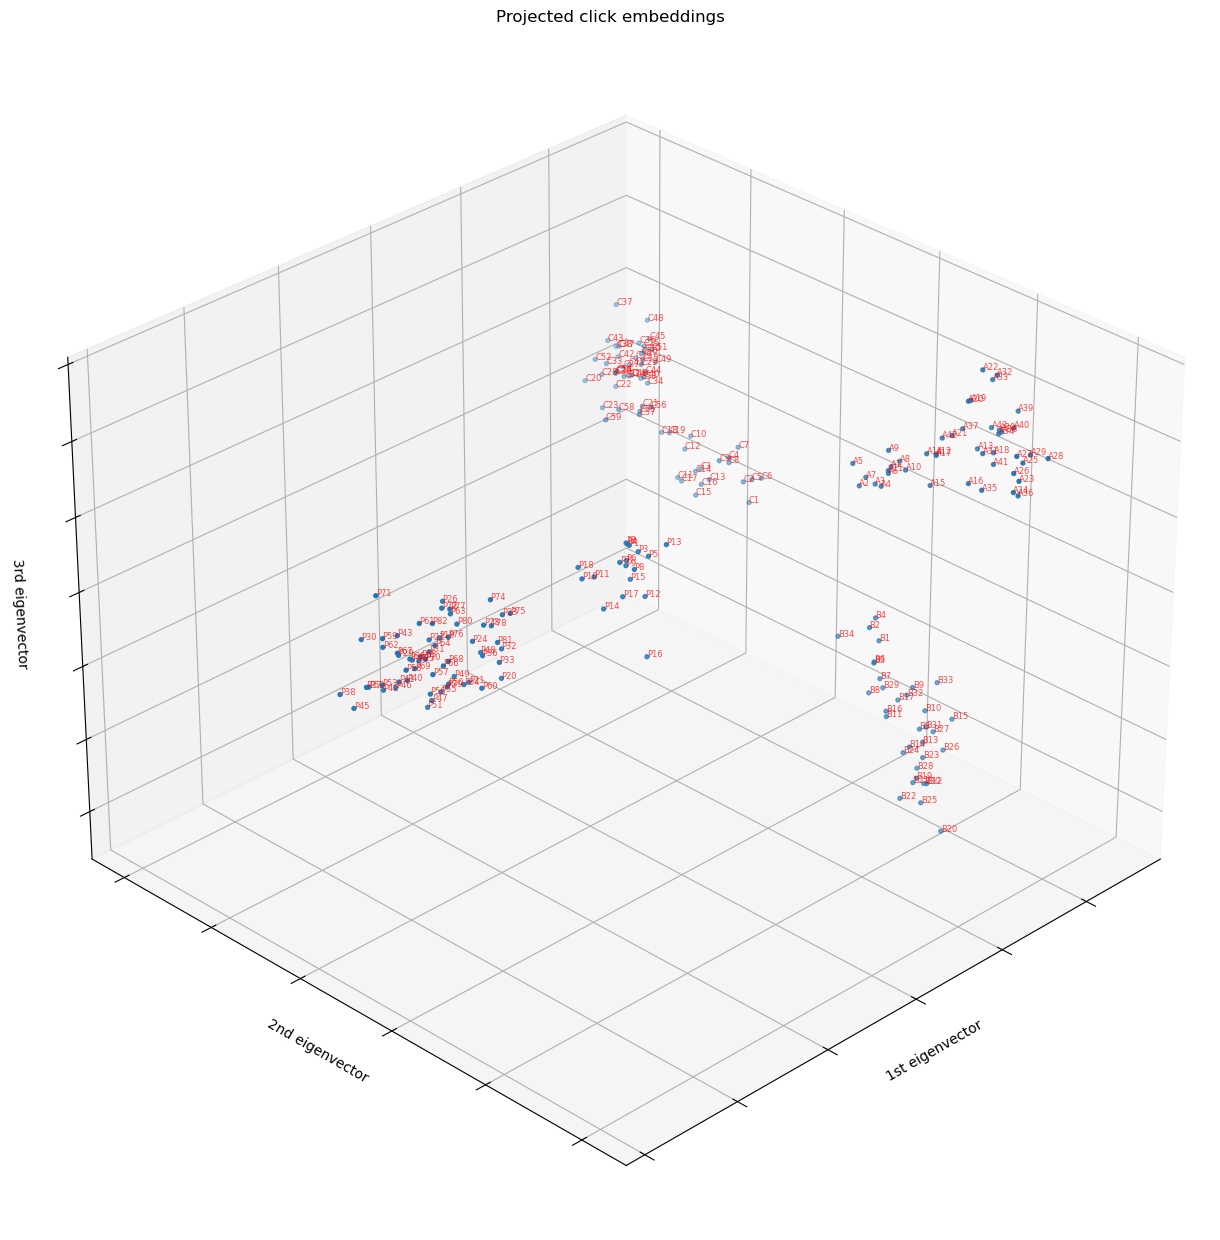

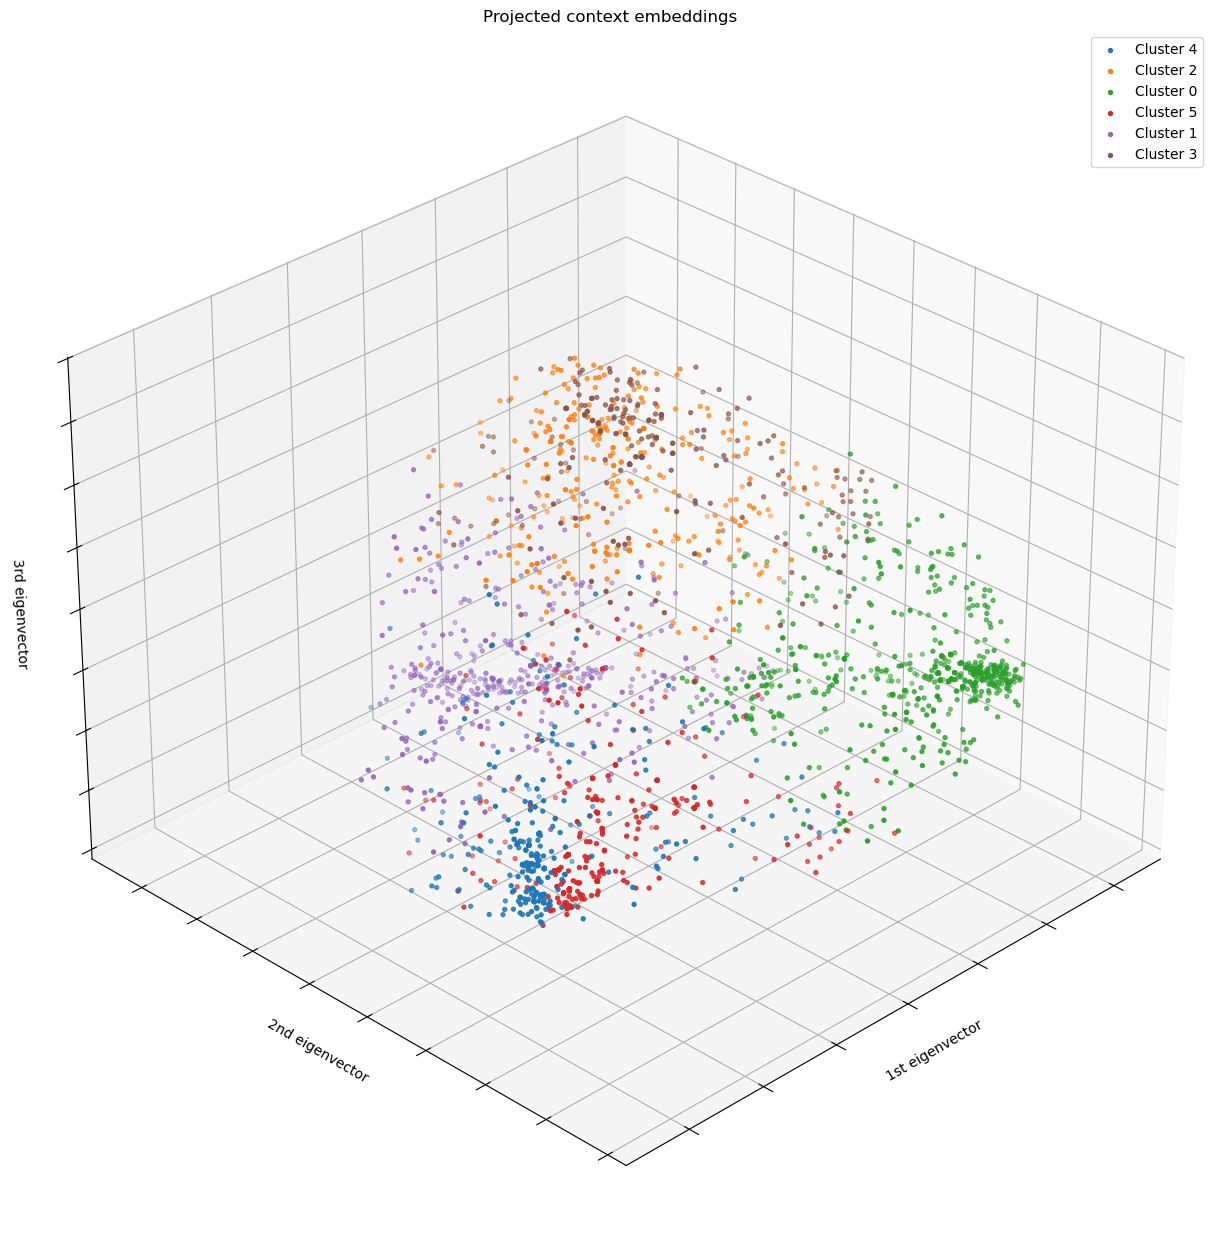

In [4]:
from pyspark.ml.feature import PCA
from pyspark.ml.functions import vector_to_array
import numpy as np
tokens_ = tokens.join(vectors.withColumnRenamed("word", "id"), on = "id", how= "left").dropna()
clicks_3d = PCA(inputCol="vector", outputCol="reduced", k = 3).fit(tokens_).transform(tokens_).select("page 2 (clothing model)", "reduced")
clicks_3d = clicks_3d.withColumn("reduced", vector_to_array(F.col("reduced"))).toPandas()
coords = np.array(clicks_3d["reduced"].tolist())
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 12))
ax = Axes3D(fig, azim=45)
fig.add_axes(ax)
ax.scatter(coords[:, 0],coords[:, 1],coords[:, 2], s = 8)
for i, word in clicks_3d["page 2 (clothing model)"].items(): 
    ax.text(coords[i, 0] ,coords[i, 1], coords[i, 2], word, fontsize=6, color = "red", alpha = 0.7)
ax.set_title("Projected click embeddings")
ax.set_xlabel("1st eigenvector")
ax.xaxis.set_ticklabels([])
ax.set_ylabel("2nd eigenvector")
ax.yaxis.set_ticklabels([])
ax.set_zlabel("3rd eigenvector")
ax.zaxis.set_ticklabels([])
plt.show()

sessions_3d = PCA(inputCol="context_norm", outputCol="reduced", k = 3).fit(model_output).transform(model_output).sampleBy("pred", fractions={k:0.1 for k in range(0,6)})
sessions_3d = sessions_3d.select("pred", "reduced")
sessions_3d = sessions_3d.withColumn("reduced", vector_to_array(F.col("reduced"))).toPandas()
coords = np.array(sessions_3d["reduced"].tolist())
n_clusters = sessions_3d["pred"].unique().tolist()
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 12))
ax = Axes3D(fig, azim=45)
fig.add_axes(ax)
for c in n_clusters:
    indeces = sessions_3d.loc[sessions_3d["pred"] == c].index
    ax.scatter(coords[indeces, 0], coords[indeces, 1],coords[indeces, 2], s = 8, label = f"Cluster {c}")
ax.set_title("Projected context embeddings")
ax.set_xlabel("1st eigenvector")
ax.xaxis.set_ticklabels([])
ax.set_ylabel("2nd eigenvector")
ax.yaxis.set_ticklabels([])
ax.set_zlabel("3rd eigenvector")
ax.zaxis.set_ticklabels([])
plt.legend()
plt.show()

In [5]:
import warnings
warnings.simplefilter("ignore", FutureWarning)

from pyspark.sql import Window
from pyspark.sql import DataFrame
def analyze_clusters(data: DataFrame, cluster_id_col: str, top_number: int = 5):
    print("CLUSTER PROFILES:")
    data = data.withColumn("model", F.concat_ws("", "model_letter", "model_number"))
    profiles = data.groupBy(cluster_id_col).agg(
        F.avg("price").alias("avg_price"),
        F.mode("price").alias("top_price"),
        F.median("price").alias("median_price"),
        F.stddev("price").alias("price_std"),
        F.percentile("price", 0.05).alias("hi"),
        F.percentile("price", 0.95).alias("lo"),
        F.percentile("price", 0.25).alias("q1"),
        F.percentile("price", 0.75).alias("q3"),
        F.countDistinct("*").alias("cluster_size_events"),
        F.countDistinct("session ID").alias("cluster_size_sessions"),
        F.countDistinct("colour").alias("colour_diversity"),
        F.mode("colour").alias("top_colour"),
        F.countDistinct("model_letter", "model_number").alias("model_diversity"),
        F.mode("model_letter").alias("top_model_letter"),
        F.countDistinct("main_category").alias("total_categories"),
        F.mode("main_category").alias("top_category"),
        F.mean("page").alias("avg_page_depth"),
        F.mean(F.col("model photography") - 1).alias("photography_probability"),
        F.mode("country").alias("top_region"),
        F.collect_set("model").alias("product_set"),
        F.collect_set("main_category").alias("category_set"),
        F.collect_set("colour").alias("color_set")
    )
    counts = data.groupBy("pred", "model").count()
    w = Window.partitionBy("pred").orderBy(F.desc("count"))
    top_products = (counts.withColumn("rank", F.row_number().over(w)).filter(F.col("rank") <= top_number))

    top_categories = data.groupBy("main_category", "pred").count()

    counts = data.groupBy("colour", "pred").count()
    top_colors = (counts.withColumn("rank", F.row_number().over(w)).filter(F.col("rank") <= top_number))

    return profiles, top_products, top_categories, top_colors
profiles, top_products, top_categories, top_colors = analyze_clusters(df, "pred")
top_categories.show()
top_products.show()
top_colors.show()
profiles.show()

CLUSTER PROFILES:


+-------------+----+-----+
|main_category|pred|count|
+-------------+----+-----+
|            1|   0|31311|
|            3|   1| 5234|
|            2|   2| 4027|
|            2|   3| 1782|
|            1|   2| 6141|
|            4|   0| 4056|
|            1|   1| 5943|
|            1|   3| 2206|
|            3|   5| 1388|
|            2|   5|10298|
|            1|   4| 2310|
|            3|   3| 8727|
|            4|   3| 1383|
|            2|   1| 3982|
|            2|   4|14498|
|            2|   0| 3821|
|            3|   2|16731|
|            1|   5| 1831|
|            3|   4| 2160|
|            4|   2| 3338|
+-------------+----+-----+
only showing top 20 rows


+----+-----+-----+----+
|pred|model|count|rank|
+----+-----+-----+----+
|   0|   A2| 2108|   1|
|   0|  A11| 1782|   2|
|   0|   A5| 1707|   3|
|   0|  A10| 1695|   4|
|   0|   A1| 1506|   5|
|   1|   P1| 1572|   1|
|   1|   P6|  971|   2|
|   1|  P16|  851|   3|
|   1|  P15|  838|   4|
|   1|   P3|  776|   5|
|   2|  C56|  671|   1|
|   2|  C40|  644|   2|
|   2|  C49|  525|   3|
|   2|  C50|  523|   4|
|   2|  C41|  473|   5|
|   3|   C5|  667|   1|
|   3|  C17|  588|   2|
|   3|  C14|  567|   3|
|   3|   C1|  552|   4|
|   3|   C2|  510|   5|
+----+-----+-----+----+
only showing top 20 rows


+------+----+-----+----+
|colour|pred|count|rank|
+------+----+-----+----+
|     3|   0|17379|   1|
|     2|   0| 6528|   2|
|     1|   0| 3986|   3|
|     4|   0| 3416|   4|
|     6|   0| 3294|   5|
|     2|   1| 8613|   1|
|     4|   1| 6804|   2|
|     3|   1| 5525|   3|
|    14|   1| 4577|   4|
|     6|   1| 4171|   5|
|    14|   2| 5105|   1|
|     2|   2| 4854|   2|
|     6|   2| 4318|   3|
|     3|   2| 2744|   4|
|     4|   2| 2406|   5|
|     9|   3| 2022|   1|
|    14|   3| 1668|   2|
|     6|   3| 1648|   3|
|     2|   3| 1537|   4|
|     4|   3| 1535|   5|
+------+----+-----+----+
only showing top 20 rows


26/04/23 11:51:40 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----+------------------+---------+------------+------------------+----+----+----+----+-------------------+---------------------+----------------+----------+---------------+----------------+----------------+------------+------------------+-----------------------+----------+--------------------+------------+--------------------+
|pred|         avg_price|top_price|median_price|         price_std|  hi|  lo|  q1|  q3|cluster_size_events|cluster_size_sessions|colour_diversity|top_colour|model_diversity|top_model_letter|total_categories|top_category|    avg_page_depth|photography_probability|top_region|         product_set|category_set|           color_set|
+----+------------------+---------+------------+------------------+----+----+----+----+-------------------+---------------------+----------------+----------+---------------+----------------+----------------+------------+------------------+-----------------------+----------+--------------------+------------+--------------------+
|   0|45.8

In [6]:
import pandas as pd
profiles = profiles.toPandas()

### Price profiling

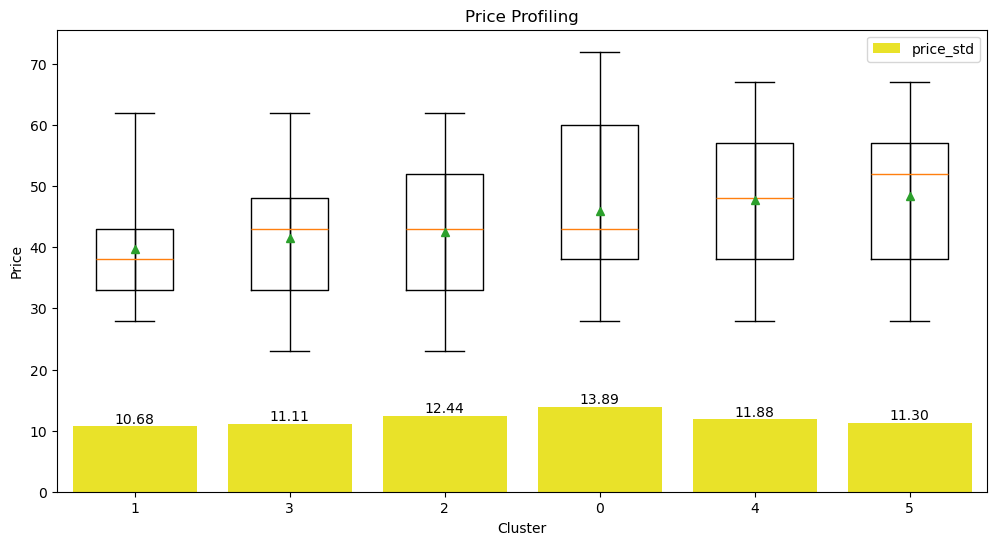

In [7]:
profiles = profiles.sort_values(by = "avg_price")
fig, ax = plt.subplots(figsize=(12, 6))
bxp_data = []
for _, row in profiles.iterrows():
    bxp_data.append({
        "label": str(row["pred"]),
        "mean": row["avg_price"],
        "q1": row["q1"],
        "med": row["median_price"],
        "q3": row["q3"],
        "whislo": row["lo"],
        "whishi": row["hi"],
        "fliers": []  # no raw data
    })
ax.bxp(bxp_data, showfliers=False, showmeans=True)
ax.bar(x = range(1, len(profiles)+1), height = profiles["price_std"], label = "price_std", color = "#E9E229")
plt.bar_label(ax.containers[0], fmt="%.2f")
ax.set_xlabel("Cluster")
ax.set_ylabel("Price")
plt.legend()
plt.title("Price Profiling")
plt.show()

### Cluster size (events + sessions)

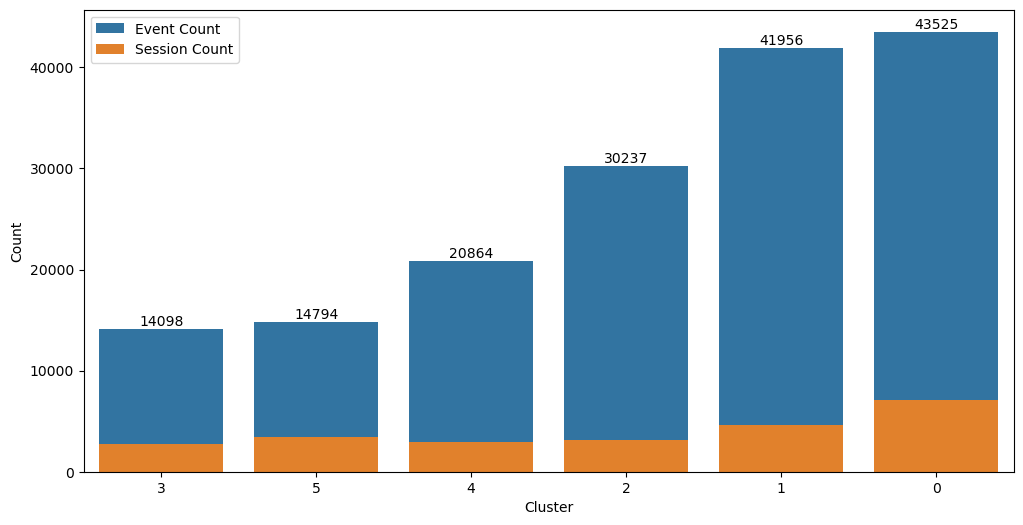

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
profiles.sort_values(by="cluster_size_events", inplace=True)
sns.barplot(profiles, x = profiles["pred"].astype(str), y = "cluster_size_events", ax =ax, label = "Event Count")
sns.barplot(profiles, x = profiles["pred"].astype(str), y = "cluster_size_sessions", ax =ax, label = "Session Count")
plt.bar_label(ax.containers[0])
plt.legend()
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

### Color and model diversity

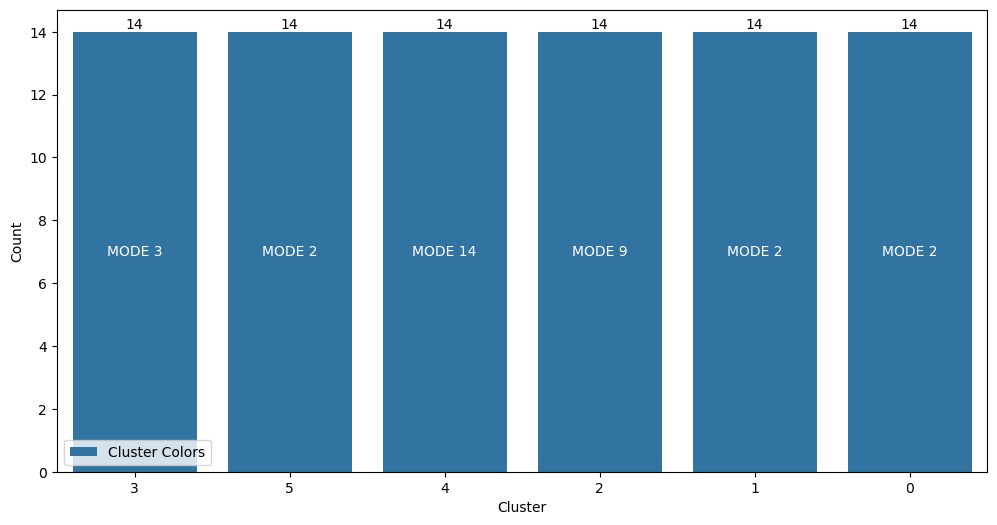

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
profiles.sort_values(by="colour_diversity", inplace=True)
sns.barplot(x = profiles["pred"].astype(str), y = profiles["colour_diversity"], label = "Cluster Colors", ax=ax)
plt.bar_label(ax.containers[0])
for i, p in enumerate(ax.patches):
    value = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() / 2, "MODE " + str(profiles["top_colour"][i]), ha="center", va="center", color="white")
plt.legend()
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

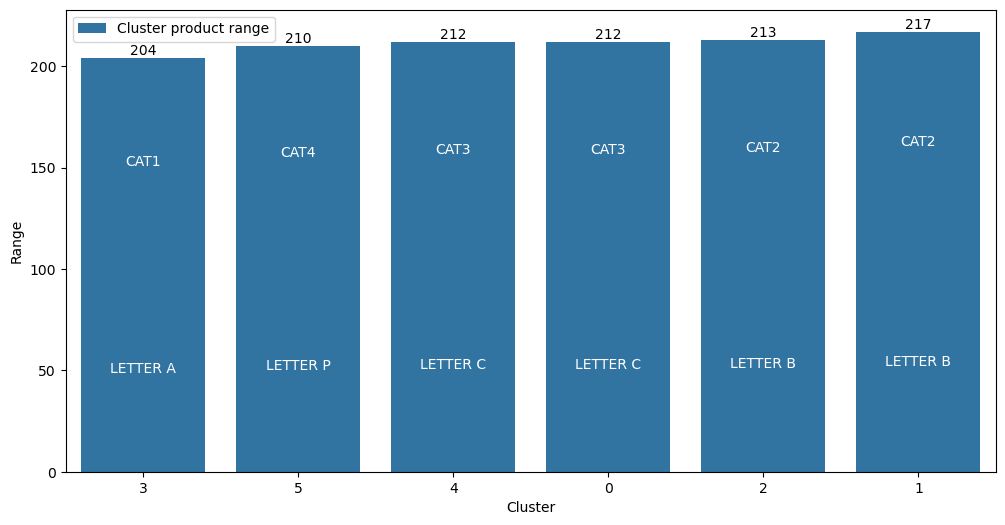

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
profiles.sort_values(by="model_diversity", inplace=True)
sns.barplot(x = profiles["pred"].astype(str), y = profiles["model_diversity"], label = "Cluster product range", ax=ax)
plt.bar_label(ax.containers[0])
for i, p in enumerate(ax.patches):
    value = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() - p.get_height() / 4, "CAT" + str(profiles["top_category"][i]), ha="center", va="center", color="white")
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() / 4, "LETTER " + str(profiles["top_model_letter"][i]), ha="center", va="center", color="white")
plt.legend()
plt.xlabel("Cluster")
plt.ylabel("Range")
plt.show()

### Photography preference and page depth

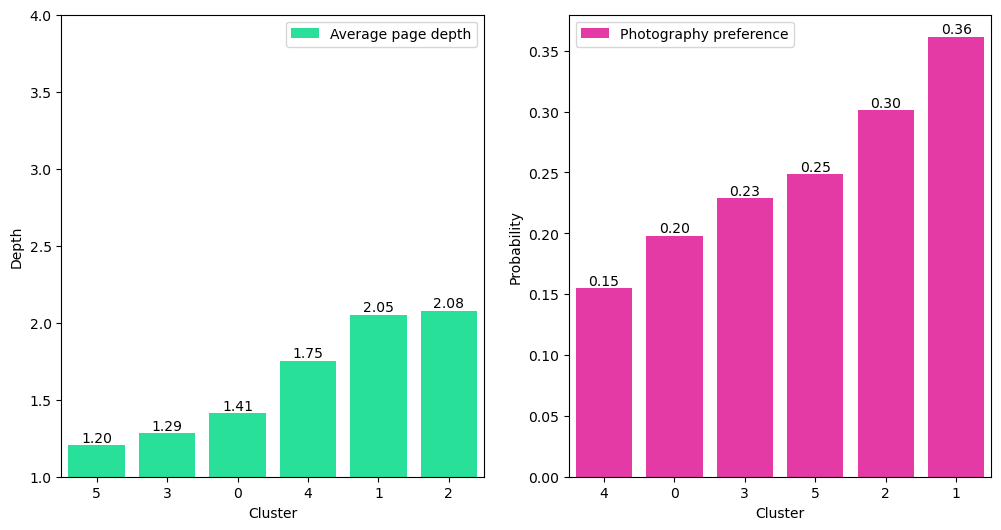

In [11]:
fig =  plt.figure(figsize=(12, 6))
cols = ["avg_page_depth", "photography_probability"]
labels = [ "Average page depth", "Photography preference"]
ylabels = ["Depth","Probability"]
colors = [ "#09FFA1",  "#FF1EAC"]
for i, col in enumerate(cols):
    ax = plt.subplot(1, 2, i+1)
    profiles.sort_values(by=col, inplace=True)
    sns.barplot(x = profiles["pred"].astype(str), y = profiles[col], label = labels[i], ax=ax, color = colors[i])
    plt.bar_label(ax.containers[0], fmt = "%.2f")
    plt.legend()
    if i == 0:
        plt.ylim((1, 4))
    plt.xlabel("Cluster")
    plt.ylabel(ylabels[i])
plt.show()


### Top categories

In [12]:
top_categories = top_categories.toPandas()

,main_category,pred,count
0,1,0,31311
1,3,1,5234
2,2,2,4027
3,2,3,1782
4,1,2,6141
5,4,0,4056
6,1,1,5943
7,1,3,2206
8,3,5,1388
9,2,5,10298


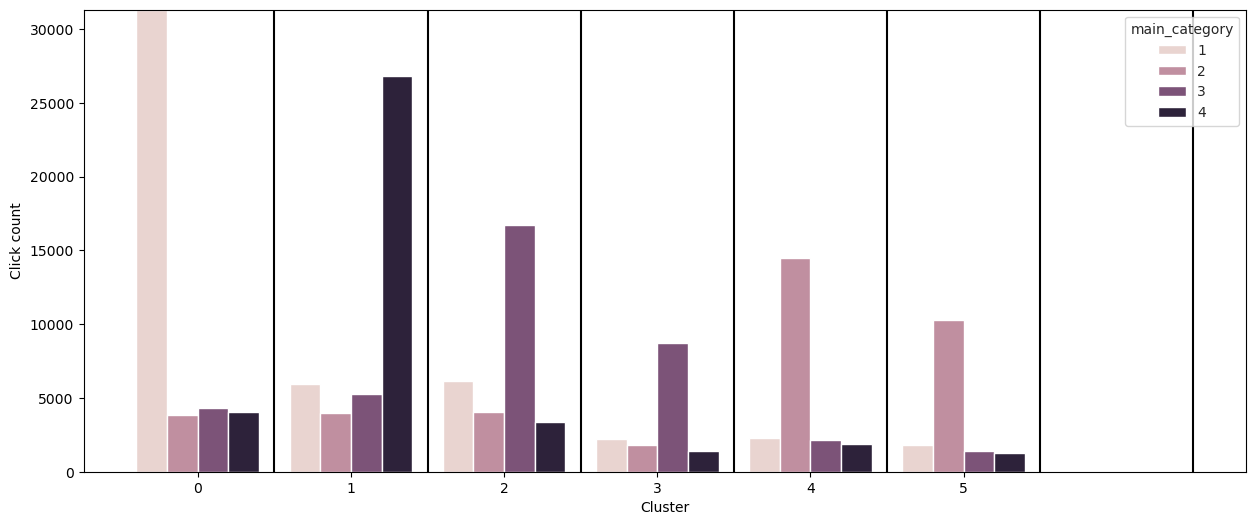

In [13]:
fig = plt.figure(figsize=(15, 6))
import numpy as np
display(top_categories)
ax = plt.axes()
sns.set_style("whitegrid")
sns.barplot(top_categories, x = "pred", y = "count", hue = "main_category", ax =ax)
plt.vlines(np.arange(0.5, 7.5), ymin= 0, ymax=top_categories["count"].max(), colors = "black")
plt.ylim(0, top_categories["count"].max())
plt.ylabel("Click count")
plt.xlabel("Cluster")
plt.show()

### Top 5 cluster products

In [14]:
top_products = top_products.toPandas()

,pred,model,count,rank
0,0,A2,2108,1
1,0,A11,1782,2
2,0,A5,1707,3
3,0,A10,1695,4
4,0,A1,1506,5
5,1,P1,1572,1
6,1,P6,971,2
7,1,P16,851,3
8,1,P15,838,4
9,1,P3,776,5


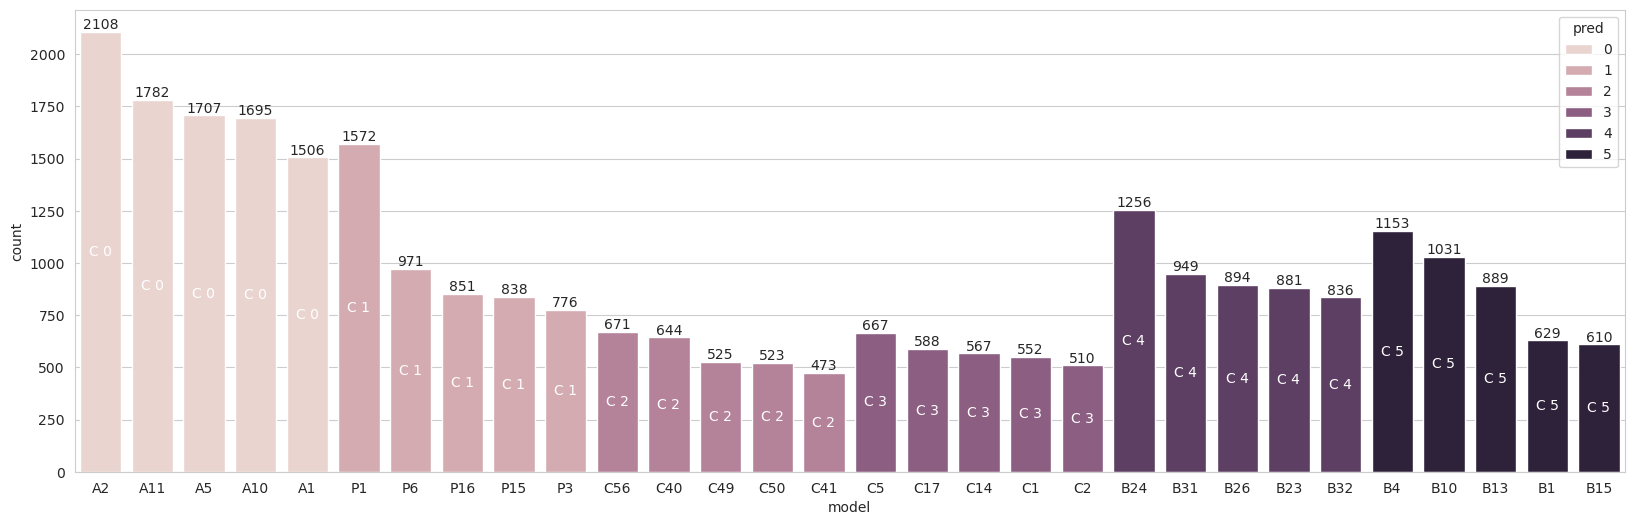

In [15]:
display(top_products)
fig = plt.figure(figsize=(20, 6))
sns.set_style("whitegrid")
ax = plt.axes()
sns.barplot(top_products, x = "model", y = "count", hue = "pred", ax =ax)
for c in ax.containers:
    plt.bar_label(c)
for i, p in enumerate(ax.patches):
    value = p.get_height()
    if i < len(top_products):
        ax.text(p.get_x() + p.get_width() / 2, p.get_height() / 2, "C " + str(top_products["pred"][i]), ha="center", va="center", color="white")
plt.show()

### Top 5 Colors

In [16]:
top_colors = top_colors.toPandas()

,colour,pred,count,rank
0,3,0,17379,1
1,2,0,6528,2
2,1,0,3986,3
3,4,0,3416,4
4,6,0,3294,5
5,2,1,8613,1
6,4,1,6804,2
7,3,1,5525,3
8,14,1,4577,4
9,6,1,4171,5


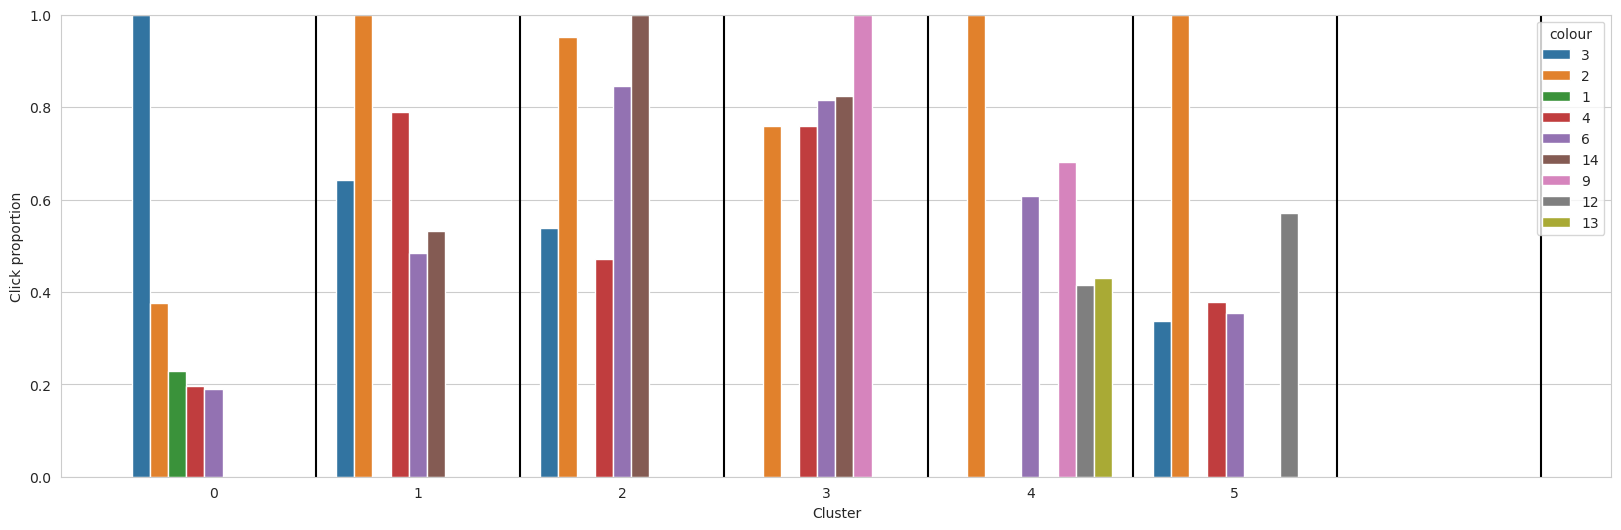

In [17]:
sns.set_style("whitegrid")
top_colors.sort_values("pred", inplace = True)
top_colors["pred"] = top_colors["pred"].astype(str)
top_colors["colour"] = top_colors["colour"].astype(str)
display(top_colors)
def normalize(group):
    group["count"] = group["count"] / group["count"].max()
    return group
top_colors = top_colors.groupby("pred", group_keys = False).apply(normalize)
fig = plt.figure(figsize=(20, 6))
ax = plt.axes()
sns.barplot(top_colors, x = "pred", y = "count", hue = "colour", ax =ax)
plt.vlines(np.arange(0.5, 7.5), ymin= 0, ymax=top_colors["count"].max(), colors = "black")
plt.xlabel("Cluster")
plt.ylabel("Click proportion")
plt.ylim(0, top_colors["count"].max())
plt.show()

### Dumping cluster profiles

In [18]:
display(profiles[["pred", "product_set", "category_set", "color_set"]])

,pred,product_set,category_set,color_set
4,4,"[C57, P30, A2, A42, P71, C12, A40, P82, C8, C2...","[1, 2, 3, 4]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]"
0,0,"[C57, P30, A2, A42, P71, C12, A40, P82, C8, C2...","[1, 2, 3, 4]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]"
3,3,"[C57, P30, C23, A2, A42, P45, C12, B9, P11, A4...","[1, 2, 3, 4]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]"
5,5,"[C57, P30, C23, A2, A42, P45, C12, B9, P11, A4...","[1, 2, 3, 4]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]"
2,2,"[C57, P30, A2, A42, P71, C12, A40, P82, C8, C2...","[1, 2, 3, 4]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]"
1,1,"[C57, P30, A2, A42, P71, C12, A40, P82, C8, C2...","[1, 2, 3, 4]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]"


In [19]:
profiles.to_csv("profile_data_w2v.csv")